# Heart Disease UCI – Exploratory Data Analysis
**AIMLCZG523 MLOps Assignment 01 | BITS Pilani WILP**

This notebook covers:
1. Dataset loading & overview
2. Missing value analysis
3. Feature distributions (histograms)
4. Class balance
5. Correlation heatmap
6. Feature-target relationships

In [24]:
import urllib.request
import pandas as pd
import os

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
COLUMNS = ["age","sex","cp","trestbps","chol","fbs","restecg",
           "thalach","exang","oldpeak","slope","ca","thal","target"]

urllib.request.urlretrieve(URL, "heart_raw.csv")
df = pd.read_csv("heart_raw.csv", header=None, names=COLUMNS, na_values="?")
df["target"] = (df["target"] > 0).astype(int)
df.to_csv("heart.csv", index=False)
print("Dataset ready:", df.shape)
df.head()

Dataset ready: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset (run data/download_data.py first, or use Colab upload)
df = pd.read_csv('heart.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1. Dataset Overview

In [26]:
print(df.dtypes)
print('\n--- Descriptive Statistics ---')
df.describe().T

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Missing Value Analysis

      missing_count  missing_pct
ca                4         1.32
thal              2         0.66


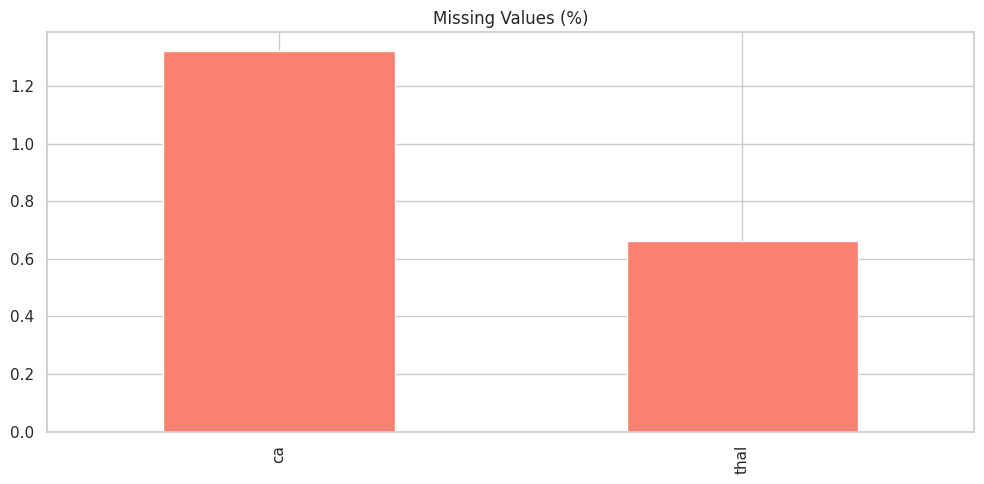

In [27]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

if missing_df.empty:
    print('No missing values found.')
else:
    print(missing_df)
    missing_df['missing_pct'].plot(kind='bar', color='salmon', title='Missing Values (%)')
    plt.tight_layout(); plt.show()

## 3. Class Distribution

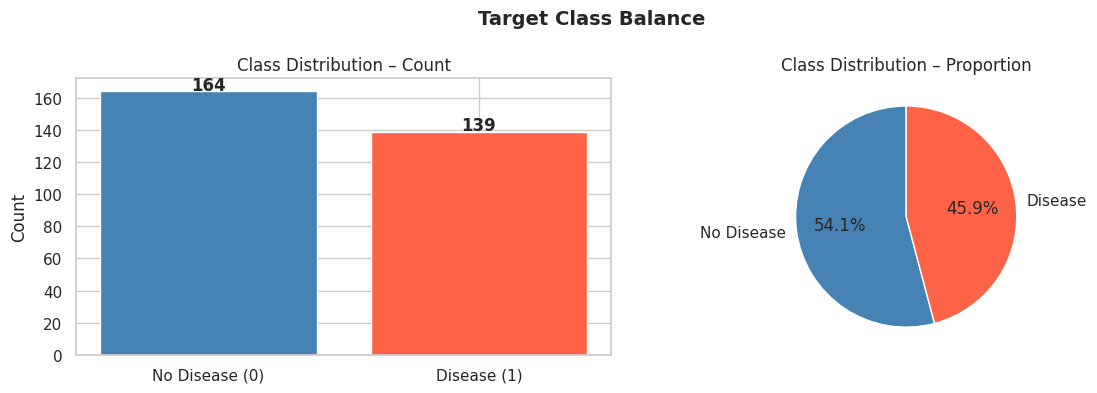

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution – Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Distribution – Proportion')

plt.suptitle('Target Class Balance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Feature Distributions – Histograms

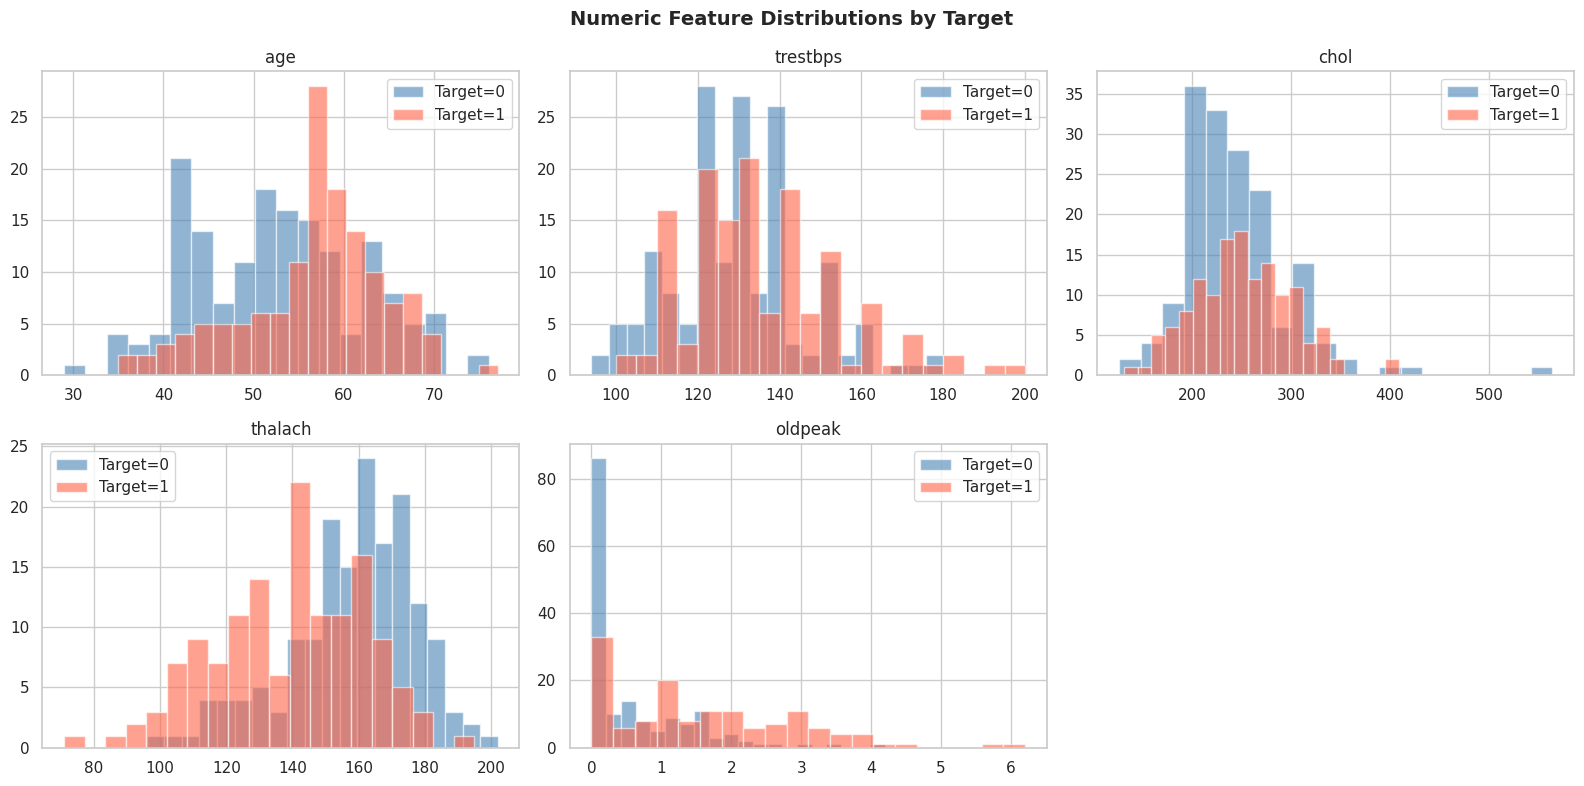

In [29]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        axes[i].hist(df[df['target'] == label][col].dropna(),
                     bins=20, alpha=0.6, color=color,
                     label=f'Target={label}')
    axes[i].set_title(col)
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Numeric Feature Distributions by Target', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Correlation Heatmap

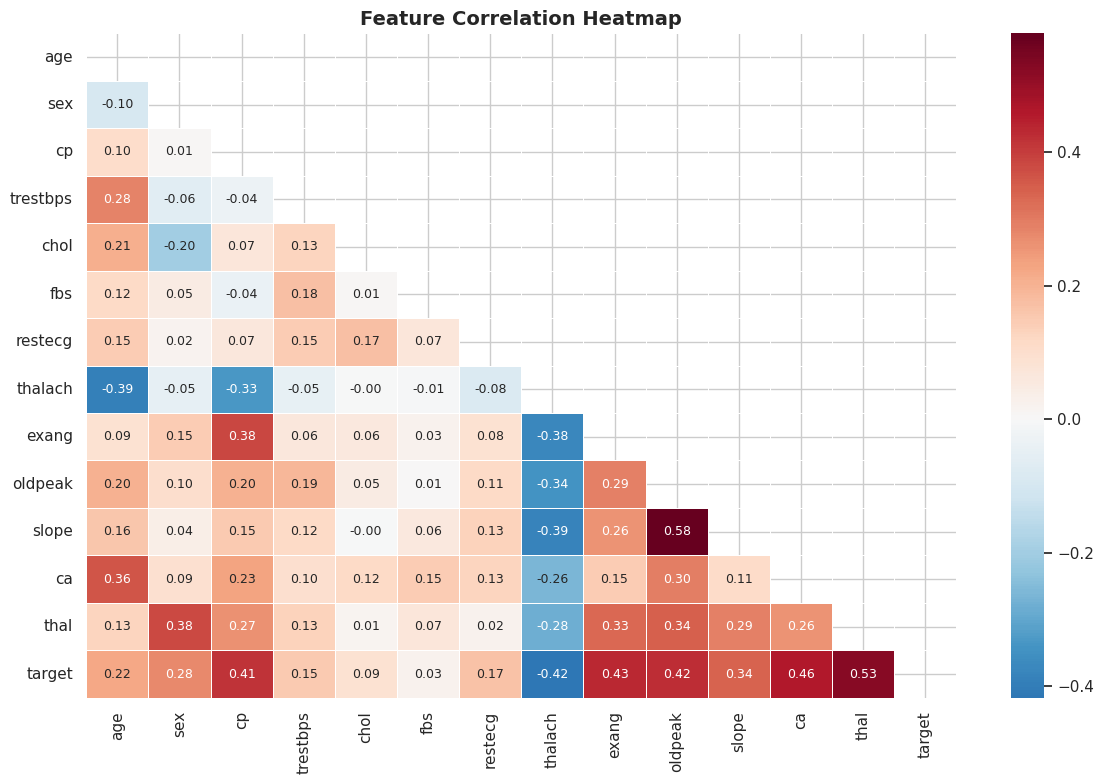

In [30]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Feature–Target Relationship Analysis

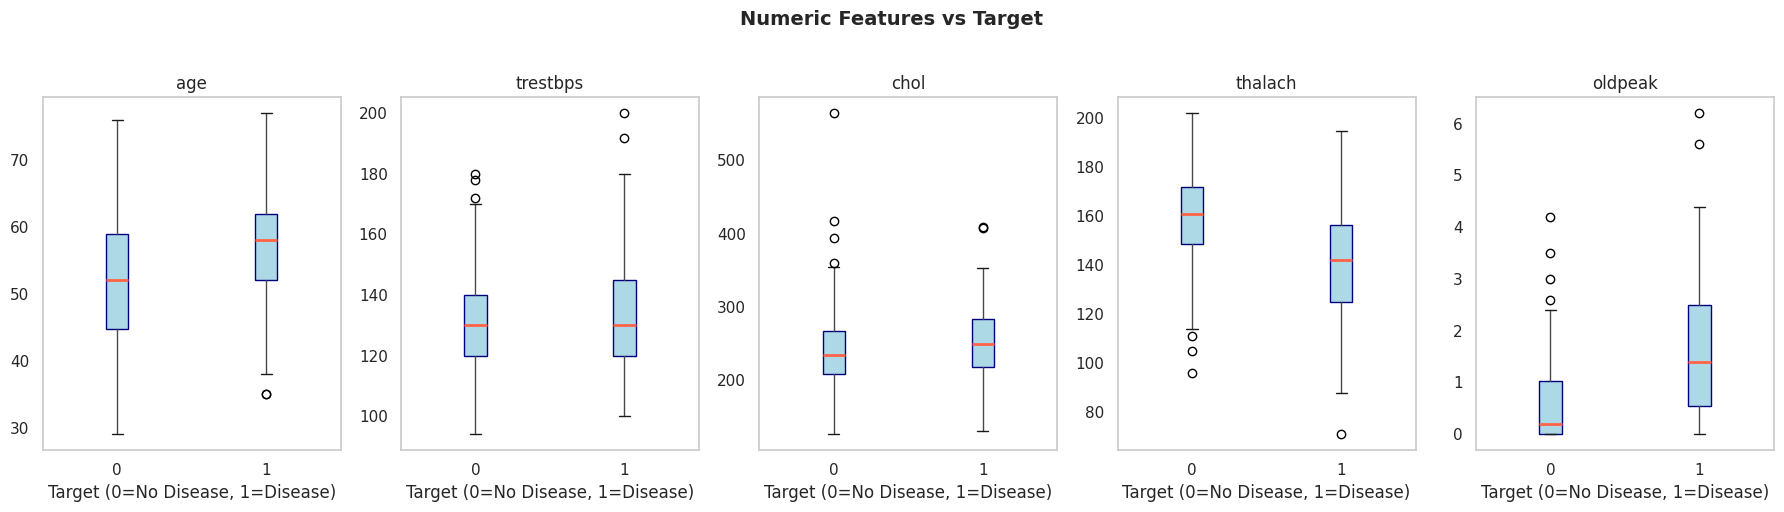

In [31]:
# Box plots for numeric features split by target
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='target', ax=axes[i], grid=False,
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')

plt.suptitle('Numeric Features vs Target', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

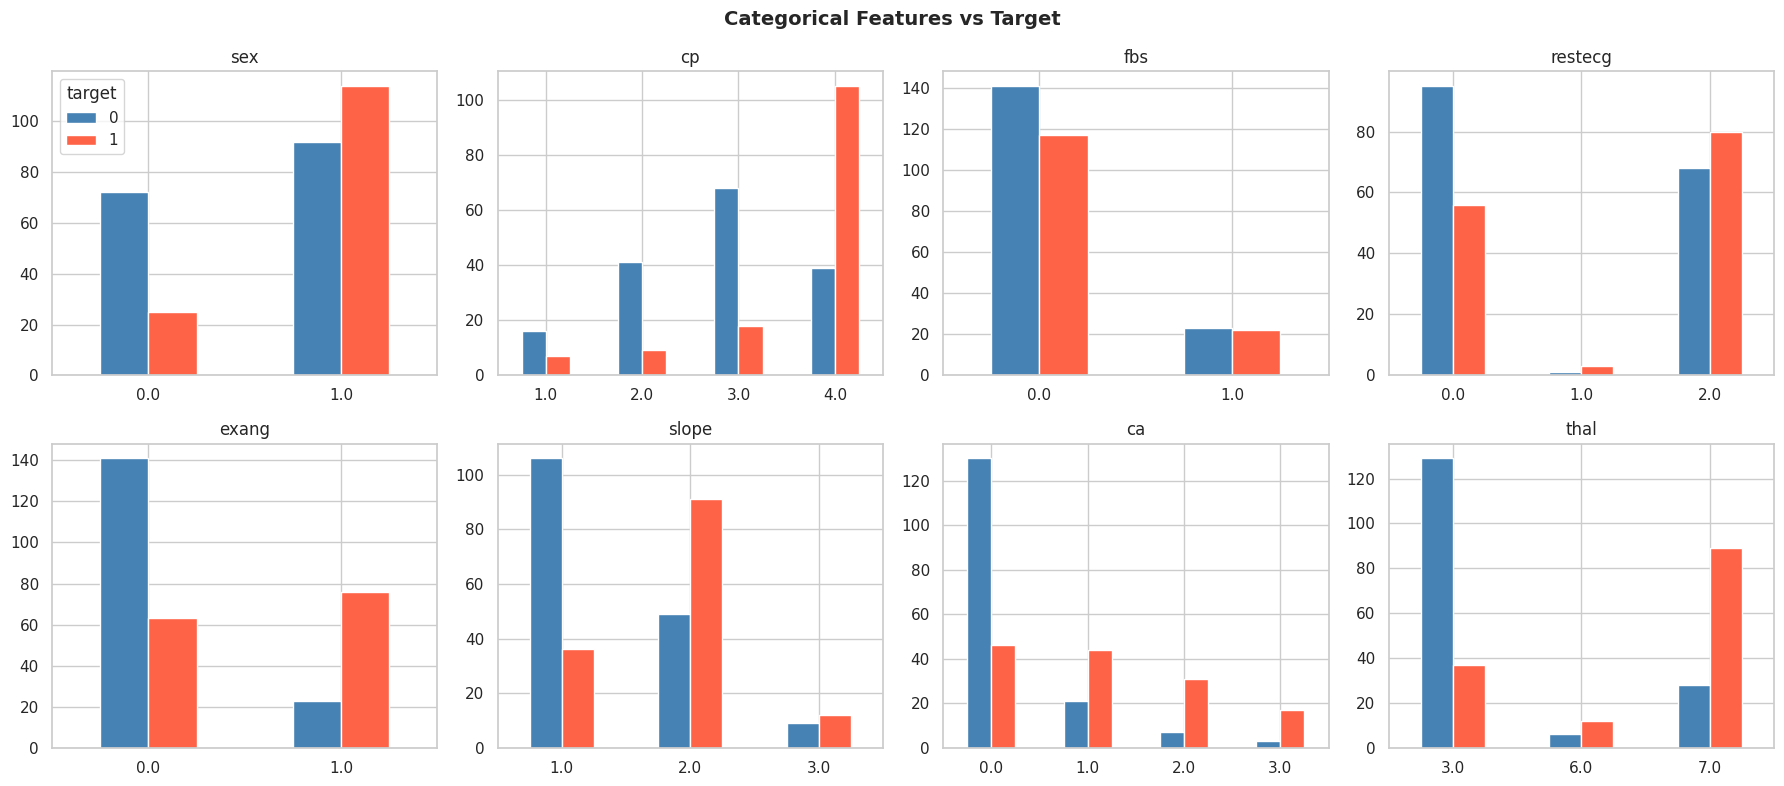

In [32]:
# Categorical features vs target
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='white', legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Key EDA Findings

**Write your own observations here after running the notebook. For example:**
- Which features show the strongest correlation with the target?
- Is the dataset balanced or imbalanced?
- Which features have missing values and what imputation strategy makes sense?
- Any outliers in blood pressure or cholesterol?

Train: 242 | Test: 61


2026/06/30 16:49:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


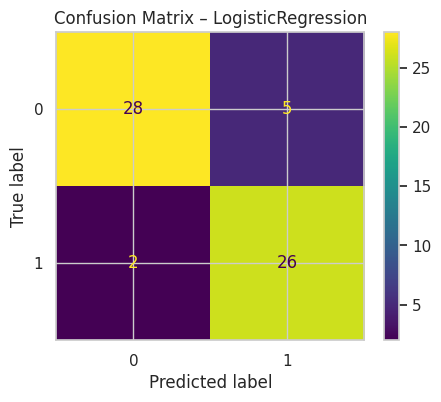

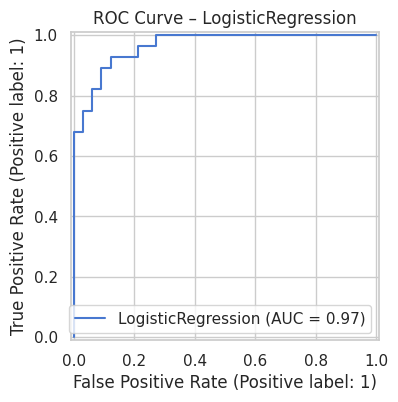


── LogisticRegression ──
  accuracy    : 0.8852
  precision   : 0.8387
  recall      : 0.9286
  f1          : 0.8814
  roc_auc     : 0.9654
  CV ROC-AUC  : 0.8982 ± 0.0481


2026/06/30 16:50:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


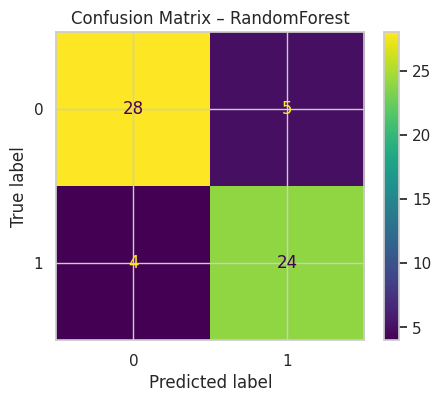

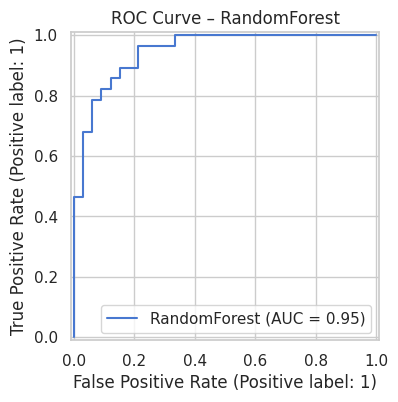


── RandomForest ──
  accuracy    : 0.8525
  precision   : 0.8276
  recall      : 0.8571
  f1          : 0.8421
  roc_auc     : 0.9470
  CV ROC-AUC  : 0.9043 ± 0.0386

Best model: LogisticRegression | ROC-AUC: 0.9654
Saved: best_model.joblib


In [33]:
import os
import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

# ── Feature definitions ───────────────────────────────────────────────
NUMERIC     = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
TARGET      = "target"

# ── Load data ─────────────────────────────────────────────────────────
df = pd.read_csv("heart.csv")
X  = df[NUMERIC + CATEGORICAL]
y  = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── Preprocessing pipeline ────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore",
                                            sparse_output=False))]), CATEGORICAL),
])

# ── Helper functions ──────────────────────────────────────────────────
def metrics(y_true, y_pred, y_prob):
    return {"accuracy":  accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred),
            "recall":    recall_score(y_true, y_pred),
            "f1":        f1_score(y_true, y_pred),
            "roc_auc":   roc_auc_score(y_true, y_prob)}

def log_cm(y_true, y_pred, name):
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax)
    ax.set_title(f"Confusion Matrix – {name}")
    path = f"/tmp/cm_{name}.png"
    fig.savefig(path, bbox_inches="tight"); plt.show(); plt.close()
    mlflow.log_artifact(path, artifact_path="plots")

def log_roc(y_true, y_prob, name):
    fig, ax = plt.subplots(figsize=(5,4))
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax, name=name)
    ax.set_title(f"ROC Curve – {name}")
    path = f"/tmp/roc_{name}.png"
    fig.savefig(path, bbox_inches="tight"); plt.show(); plt.close()
    mlflow.log_artifact(path, artifact_path="plots")

def train(name, estimator, param_grid):
    pipe = Pipeline([("pre", preprocessor), ("clf", estimator)])
    grid = {f"clf__{k}": v for k, v in param_grid.items()}
    gs   = GridSearchCV(pipe, grid, cv=5, scoring="roc_auc", n_jobs=-1)

    with mlflow.start_run(run_name=name):
        gs.fit(X_train, y_train)
        best   = gs.best_estimator_
        y_pred = best.predict(X_test)
        y_prob = best.predict_proba(X_test)[:,1]
        m      = metrics(y_test, y_pred, y_prob)
        cv     = cross_val_score(best, X_train, y_train, cv=5, scoring="roc_auc")

        mlflow.log_params(gs.best_params_)
        mlflow.log_param("model_type", name)
        mlflow.log_metrics(m)
        mlflow.log_metric("cv_roc_auc_mean", cv.mean())
        mlflow.log_metric("cv_roc_auc_std",  cv.std())
        mlflow.sklearn.log_model(
    best,
    artifact_path="model",
    skops_trusted_types=[
        "numpy.dtype",
        "sklearn.compose._column_transformer._RemainderColsList"
    ]
)

        log_cm(y_test, y_pred, name)
        log_roc(y_test, y_prob, name)

        print(f"\n── {name} ──")
        for k,v in m.items(): print(f"  {k:12s}: {v:.4f}")
        print(f"  CV ROC-AUC  : {cv.mean():.4f} ± {cv.std():.4f}")

    return best, m

# ── Run experiments ───────────────────────────────────────────────────
mlflow.set_experiment("heart-disease-classification")

lr_best, lr_m = train("LogisticRegression",
    LogisticRegression(random_state=42),
    {"C": [0.01, 0.1, 1, 10], "max_iter": [500],
     "class_weight": ["balanced", None]})

rf_best, rf_m = train("RandomForest",
    RandomForestClassifier(random_state=42),
    {"n_estimators": [100, 200], "max_depth": [None, 5, 10],
     "min_samples_split": [2, 5], "class_weight": ["balanced", None]})

# ── Save best model ───────────────────────────────────────────────────
best_model = rf_best if rf_m["roc_auc"] >= lr_m["roc_auc"] else lr_best
best_name  = "RandomForest" if rf_m["roc_auc"] >= lr_m["roc_auc"] else "LogisticRegression"
joblib.dump(best_model, "best_model.joblib")
print(f"\nBest model: {best_name} | ROC-AUC: {max(rf_m['roc_auc'], lr_m['roc_auc']):.4f}")
print("Saved: best_model.joblib")

In [34]:
from google.colab import files
files.download("best_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>